In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Illustration 10.1-1 &mdash; vapor-liquid equilibrium diagrams for an ideal mixture

**The four diagrams of Illustration 10.1-1**, for *n*-pentane / *n*-heptane: at a fixed
temperature of 50 °C, and at a fixed pressure of 1.013 bar.

The illustration is the chapter's first, and it is where the four kinds of binary phase
diagram get introduced at once &mdash; $x$-$y$, $P$-$x$-$y$ and $T$-$x$-$y$. It assumes
the mixture is **ideal**, so it obeys Raoult's law,

$$y_i P = x_i P_i^{\rm vap}(T)$$

**Raoult's law is not a separate method.** It is the general low-pressure equilibrium
relation $y_i P = x_i \gamma_i(\underline{x}, T) P_i^{\rm vap}(T)$ with every activity
coefficient set to one. The book presents Sections 10.1 and 10.2 as two procedures; they
are one procedure and one substitution, and the last section of this notebook shows that
by swapping a single argument.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from thermo.vle import ClausiusClapeyron, GammaPhi, Ideal, pxy, txy
from thermo.vle_chart import pxy_chart, txy_chart, xy_chart, tie_lines, CELSIUS
from thermo.charts import use_book_style
use_book_style()

True

## The data, and whether the problem is even solvable

The illustration gives the two vapor pressures in the integrated Clausius-Clapeyron form,
with $P$ in bar, $T$ in K and $R = 8.314$ J/(mol K):

$$\ln P_5^{\rm vap} = 10.422 - \frac{26\,799}{RT} \qquad
  \ln P_7^{\rm vap} = 11.431 - \frac{35\,200}{RT}$$

**This is not the Antoine equation**, though it is easy to read it as one. In this
two-constant form the numerator *is* the enthalpy of vaporization in J/mol (Eq. 7.7-5a),
which is why `ClausiusClapeyron` names that argument `dHvap` rather than `B`.

The illustration opens by checking the Gibbs phase rule before calculating anything &mdash;
a habit to keep, because it is what tells you the problem is well posed.

In [3]:
C5 = ClausiusClapeyron(10.422, 26799.0)      # n-pentane, as printed
C7 = ClausiusClapeyron(11.431, 35200.0)      # n-heptane

C, P_phases, r = 2, 2, 0                     # components, phases, reactions
F = C - r - P_phases + 2
print(f"Gibbs phase rule:  F = {C} - {r} - {P_phases} + 2 = {F} degrees of freedom")
print("Fix T (or P), then one liquid composition -> the state is determined.\n")

mix = GammaPhi([C5, C7], Ideal(), names=["n-pentane", "n-heptane"])
for T in (323.15, 373.15):
    P5, P7 = mix.Psat(T) / 1e5
    print(f"T = {T - 273.15:5.1f} C:  Pvap(C5) = {P5:7.4f} bar   Pvap(C7) = {P7:7.4f} bar")

Gibbs phase rule:  F = 2 - 0 - 2 + 2 = 2 degrees of freedom
Fix T (or P), then one liquid composition -> the state is determined.

T =  50.0 C:  Pvap(C5) =  1.5648 bar   Pvap(C7) =  0.1882 bar
T = 100.0 C:  Pvap(C5) =  5.9551 bar   Pvap(C7) =  1.0892 bar


## (a) A constant temperature of 50 °C

At fixed $T$ both vapor pressures are fixed, so the bubble-point pressure is **explicit**
&mdash; there is nothing to iterate:

$$P = x_5 P_5^{\rm vap} + (1 - x_5) P_7^{\rm vap} \qquad y_5 = \frac{x_5 P_5^{\rm vap}}{P}$$

The total pressure is therefore *linear* in $x_5$, which is the signature of an ideal
mixture and the thing every nonideal system in Section 10.2 departs from.

In [4]:
T_a = 273.15 + 50.0
x5, y5, P = pxy(mix, T_a)

# the bubble line is exactly linear in x -- check it rather than assert it
P5, P7 = mix.Psat(T_a)
print("bubble line is linear in x to machine precision:",
      np.allclose(P, x5 * P5 + (1 - x5) * P7))

print(f"\n  x5      y5       P (bar)")
for a in np.linspace(0, 1, 11):
    Pi, yi = mix.bubble_pressure([a, 1 - a], T_a)
    print(f"  {a:.1f}   {yi[0]:.4f}   {Pi/1e5:.4f}")

bubble line is linear in x to machine precision: True

  x5      y5       P (bar)
  0.0   0.0000   0.1882
  0.1   0.4801   0.3259
  0.2   0.6751   0.4636
  0.3   0.7808   0.6012
  0.4   0.8471   0.7389
  0.5   0.8926   0.8765
  0.6   0.9258   1.0142
  0.7   0.9510   1.1518
  0.8   0.9708   1.2895
  0.9   0.9868   1.4271
  1.0   1.0000   1.5648


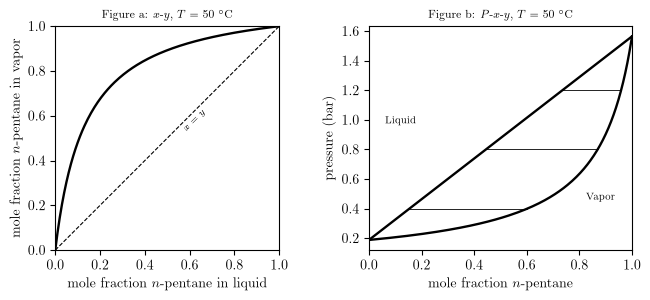

In [5]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(6.8, 3.1))

xy_chart(axa, x5, y5, species="$n$-pentane")
axa.set_title("Figure a: $x$-$y$, $T$ = 50 $^\\circ$C", fontsize=8)

pxy_chart(axb, x5, y5, P, species="$n$-pentane")
tie_lines(axb, x5, y5, P, [0.4e5, 0.8e5, 1.2e5])
axb.set_title("Figure b: $P$-$x$-$y$, $T$ = 50 $^\\circ$C", fontsize=8)

fig.tight_layout()

## (b) A constant pressure of 1.013 bar

Now the temperature is unknown and the vapor pressures depend on it nonlinearly, so each
composition needs a root find:

$$\sum_i x_i P_i^{\rm vap}(T) = 1.013\ \text{bar}$$

The illustration describes this as guess-and-check &mdash; "if the calculated pressure is
greater than 1.013 bar, a lower temperature is guessed and the calculation repeated." That
is exactly what `bubble_temperature` does, with a bracketing solver instead of a person.

In [6]:
P_b = 1.013e5
x5b, y5b, Tb = txy(mix, P_b)

print(f"pure n-pentane boils at {C5.T_sat(P_b) - 273.15:.2f} C   (lit. ~36.1)")
print(f"pure n-heptane boils at {C7.T_sat(P_b) - 273.15:.2f} C   (lit. ~98.4)")
print(f"\nbubble T at x5 = 0.5: {np.interp(0.5, x5b, Tb) - 273.15:.2f} C")

pure n-pentane boils at 36.50 C   (lit. ~36.1)
pure n-heptane boils at 97.63 C   (lit. ~98.4)

bubble T at x5 = 0.5: 54.60 C


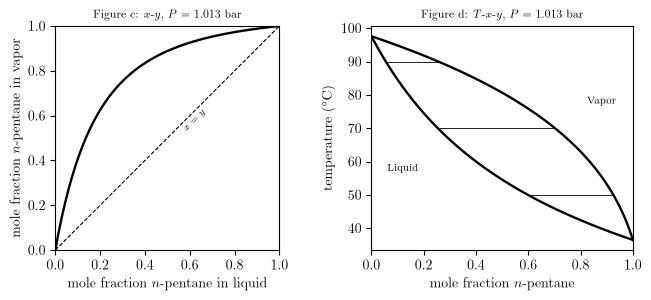

In [7]:
fig, (axc, axd) = plt.subplots(1, 2, figsize=(6.8, 3.1))

xy_chart(axc, x5b, y5b, species="$n$-pentane")
axc.set_title("Figure c: $x$-$y$, $P$ = 1.013 bar", fontsize=8)

txy_chart(axd, x5b, y5b, Tb, species="$n$-pentane", unit=CELSIUS)
tie_lines(axd, x5b, y5b, Tb, [50 + 273.15, 70 + 273.15, 90 + 273.15], unit=CELSIUS)
axd.set_title("Figure d: $T$-$x$-$y$, $P$ = 1.013 bar", fontsize=8)

fig.tight_layout()

### Why figures b and d are upside down relative to each other

The illustration's Comment asks the reader to work out "why the liquid region is at the
top part of figure b and at the bottom part of figure d." Both charts above label their
regions, so the answer is visible: raising the **pressure** on a vapor condenses it, so
liquid is *up* on a $P$-$x$-$y$; raising the **temperature** on a liquid boils it, so
liquid is *down* on a $T$-$x$-$y$.

**A correction to the printed caption.** The caption calls Figure d *"The P-x-y
diagram for the n-pentane + n-heptane mixture at P = 1.013 bar"* &mdash; but a diagram at
fixed pressure cannot have pressure as its ordinate, and the illustration's own text says
Figure d "gives the equilibrium **temperature** as a function of both the vapor and liquid
compositions." It is a $T$-$x$-$y$ diagram, and is drawn as one here.

The tie lines make the other half of the Comment concrete: they are horizontal on both
diagrams, but they are lines of constant *pressure* on figure b and constant *temperature*
on figure d.

## Raoult's law is $\gamma = 1$, and nothing else

The claim at the top of this notebook is cheap to check. `GammaPhi` was built above with
`Ideal()`; hand it a real activity-coefficient model instead and the same three lines of
code produce a nonideal diagram. Nothing else changes &mdash; not the solver, not the
diagram code, not the call signature.

That is the whole of Section 10.2 in advance, and it is also why Section 10.3 can reuse
this notebook's plotting: an equation-of-state mixture answers `bubble_pressure` too.

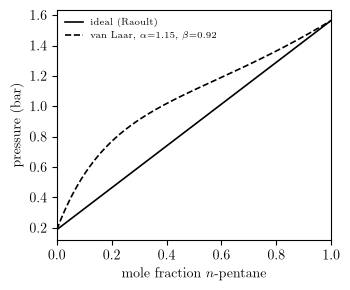

In [8]:
from thermo.activity_models import VanLaar

ideal_like = GammaPhi([C5, C7], Ideal())
nonideal   = GammaPhi([C5, C7], VanLaar(1.15, 0.92))   # a made-up but plausible pair

fig, ax = plt.subplots(figsize=(3.6, 3.0))
for m, style, lab in ((ideal_like, "-", "ideal (Raoult)"),
                      (nonideal, "--", "van Laar, $\\alpha$=1.15, $\\beta$=0.92")):
    xx, yy, PP = pxy(m, T_a)
    ax.plot(xx, PP / 1e5, style, color="k", lw=1.2, label=lab)
ax.set_xlabel("mole fraction $n$-pentane"); ax.set_ylabel("pressure (bar)")
ax.set_xlim(0, 1); ax.legend(frameon=False, fontsize=6.5)
fig.tight_layout()

## Print art

The four panels again, each drawn on its own as the book prints them. They are written to `pdf/`.

Two deliberate departures from the paired figures above. Each panel is sized for a single
column rather than a half-spread, and **the titles come off**: in the book the caption
carries that information, and a title inside the art duplicates it.

In [9]:
# --- Print art: Illustration 10.1-1, figures a-d ---------------------------
# Stage as deliverables/figures/print-bw/ch10/c10uf001{a,b,c,d}.pdf
#
# FOUR separate files, not two pairs: the book sets these as four numbered panels
# with four captions (c10uf001a-d), so the art has to match that granularity.
#
# Figure d is drawn as a T-x-y. The printed caption calls it a P-x-y, which cannot be
# right at fixed pressure and contradicts the illustration's own text; see the
# note above. The caption needs correcting in the manuscript, not the art.
#
# No titles: the caption carries them in print. No color anywhere -- the bubble
# and dew lines are identified by the Liquid/Vapor region labels, as in the printed art.
import os
os.makedirs("pdf", exist_ok=True)

SIZE = (3.4, 2.9)
panels = [
    ("a", lambda a: xy_chart(a, x5, y5, species="$n$-pentane")),
    ("b", lambda a: (pxy_chart(a, x5, y5, P, species="$n$-pentane"),
                     tie_lines(a, x5, y5, P, [0.4e5, 0.8e5, 1.2e5]))),
    ("c", lambda a: xy_chart(a, x5b, y5b, species="$n$-pentane")),
    ("d", lambda a: (txy_chart(a, x5b, y5b, Tb, species="$n$-pentane", unit=CELSIUS),
                     tie_lines(a, x5b, y5b, Tb, [323.15, 343.15, 363.15], unit=CELSIUS))),
]
for tag, draw in panels:
    f, a = plt.subplots(figsize=SIZE)
    draw(a)
    f.tight_layout()
    f.savefig(f"pdf/Illustration_10.1-1{tag}.pdf", dpi=300, bbox_inches="tight")
    plt.close(f)
print("wrote", ", ".join(f"pdf/Illustration_10.1-1{t}.pdf" for t, _ in panels))

wrote pdf/Illustration_10.1-1a.pdf, pdf/Illustration_10.1-1b.pdf, pdf/Illustration_10.1-1c.pdf, pdf/Illustration_10.1-1d.pdf


## Your turn

1. The two curves above differ only in the activity-coefficient model. At what value of
   $\alpha = \beta$ does the van Laar mixture stop showing an azeotrope? (`thermo.vle`
   has an `azeotrope` function; it returns `None` when there is none.)
2. Figure b's tie lines were drawn at 0.4, 0.8 and 1.2 bar. What happens to the tie line
   as it approaches either pure end, and what does its *length* measure?
3. Illustration 10.1-2 does this for a **ternary** &mdash; 25 % pentane, 45 % hexane,
   30 % heptane. `GammaPhi` takes any number of species. What does an $x$-$y$ diagram
   mean for three components, and why does the book stop drawing them?